In [1]:
# Set up the file path
import sys
import os

parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
target_directory = os.path.join(parent_dir, '/local0/scratch/git/CRN-GenerativeAI/FINAL_nicolo/stochastic_RPA_3s_6r_MAK_REINFORCE')
sys.path.append(parent_dir)
print('Working directory set to:', parent_dir)
print('Target directory set to:', target_directory)

Working directory set to: /local0/scratch/git/CRN-GenerativeAI
Target directory set to: /local0/scratch/git/CRN-GenerativeAI/FINAL_nicolo/stochastic_RPA_3s_6r_MAK_REINFORCE


In [2]:
# Import general packages
from openpyxl import Workbook, load_workbook
from openpyxl.utils import get_column_letter
from datetime import datetime
import torch
from matplotlib import pyplot as plt
from pytorch_lightning.loggers import CometLogger
import numpy as np
from itertools import product
from tqdm import tqdm

# Import Agent-Environment packages
from RL4CRN.environments.environment import Environment
from RL4CRN.environments.parallel_environments import ParallelEnvironments
from RL4CRN.environments.serial_environments import SerialEnvironments
from RL4CRN.agents.reinforce_agent import REINFORCEAgent
from RL4CRN.policies.add_reaction_by_ordered_index import AddReactionByOrderedIndex
from RL4CRN.policies.add_reaction_by_index import AddReactionByIndex

# Import Interface packages
from RL4CRN.env2agent_interface.explicit_observer import ExplicitObserver
from RL4CRN.env2agent_interface.explicit_tensorizer import ExplicitTensorizer
from RL4CRN.agent2env_interface.library_actuator import LibraryActuator
from RL4CRN.agent2env_interface.iocrn_stepper import IOCRNStepper

# Import CRN packages
from RL4CRN.iocrns.iocrn import IOCRN
from RL4CRN.iocrns.reactions import MassAction
from RL4CRN.utils.ic import IC
from RL4CRN.iocrns.reaction_library import construct_mass_action_library

# Import Reward packages
from RL4CRN.rewards.stochastic import robust_tracking_loss_SSA

In [3]:
# Filename for loading the agent checkpoint
# load_path = '/local0/rossin/git/CRN-GenerativeAI/apps_results_MAK_REINFORCE/RPA_3species_5rxns/models/' 
# get directory of this script (must work in a jupyter notebook as well)
load_path = os.path.join(target_directory, 'models')
print('Loading models from:', load_path)

# locate all files corresponding to *.pth in the subdirectory of load path
input_paths = []
for file in os.listdir(load_path):
    if file.endswith('.pth') and not file.startswith('generated_'):
        input_paths.append(os.path.join(load_path, file))

save_flag = True                # Save the results of the obtained IOCRNs

# No logger needed
logger = None

Loading models from: /local0/scratch/git/CRN-GenerativeAI/FINAL_nicolo/stochastic_RPA_3s_6r_MAK_REINFORCE/models


In [4]:
# Construct the template CRN
scale = 3.0
r1 = MassAction(reactant_labels=[], product_labels=['Z_1'], input_channels=['u_1'], params=[scale], params_controllability=[True])
r2 = MassAction(reactant_labels=['X_1'], product_labels=[], input_channels=['u_2'], params=[1.], params_controllability=[True])
crn_template = IOCRN([r1, r2], output_labels=['X_1'])
crn_template.compile()
p = crn_template.num_inputs # Number of inputs of the IOCRNs
print("Template CRN:")
print(crn_template)

# Construct the library of possible reactions
species_labels = ['X_1', 'Z_1', 'Z_2'] + ['Z_3']
library = construct_mass_action_library(species_labels=species_labels, order=2)
crn_template.set_library_context(library)
M = len(library.reactions) # Number of possible reactions
K = library.get_num_parameters() # Total number of parameters in all the reactions of the library
print("Library of possible reactions:")
print(library)
print("------------------------------------------------")

Template CRN:
Inputs: ['u_1', 'u_2'] 
Species: ['X_1', 'Z_1'] 
Output Species: ['X_1'] 
∅ ----> Z_1;  [MAK(3.0, u_1)]
X_1 ----> ∅;  [MAK(1.0, u_2)]
Library of possible reactions:
Number of reactions: 211
R0: ∅ ----> ∅;  [MAK(None)]
R1: ∅ ----> X_1;  [MAK(None)]
R2: ∅ ----> Z_1;  [MAK(None)]
R3: ∅ ----> Z_2;  [MAK(None)]
R4: ∅ ----> Z_3;  [MAK(None)]
R5: ∅ ----> X_1 + X_1;  [MAK(None)]
R6: ∅ ----> X_1 + Z_1;  [MAK(None)]
R7: ∅ ----> X_1 + Z_2;  [MAK(None)]
R8: ∅ ----> X_1 + Z_3;  [MAK(None)]
R9: ∅ ----> Z_1 + Z_1;  [MAK(None)]
R10: ∅ ----> Z_1 + Z_2;  [MAK(None)]
R11: ∅ ----> Z_1 + Z_3;  [MAK(None)]
R12: ∅ ----> Z_2 + Z_2;  [MAK(None)]
R13: ∅ ----> Z_2 + Z_3;  [MAK(None)]
R14: ∅ ----> Z_3 + Z_3;  [MAK(None)]
R15: X_1 ----> ∅;  [MAK(None)]
R16: X_1 ----> Z_1;  [MAK(None)]
R17: X_1 ----> Z_2;  [MAK(None)]
R18: X_1 ----> Z_3;  [MAK(None)]
R19: X_1 ----> X_1 + X_1;  [MAK(None)]
R20: X_1 ----> X_1 + Z_1;  [MAK(None)]
R21: X_1 ----> X_1 + Z_2;  [MAK(None)]
R22: X_1 ----> X_1 + Z_3;  [MAK(None

In [5]:
# Device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
print(f'Number of CPUs available: {os.cpu_count()}') 

Using device: cuda
Number of CPUs available: 8


In [6]:
# Hyperparameters
max_added_reactions = 6                             # Maximum number of reactions
N_CPUs = 4 # os.cpu_count()                         # Number of CPUs          
N = 160                                             # Number of samples (batch size)    
width = 1024                                        # Width of the neural networks  
depth = 5                                           # Depth of the neural networks 
deep_layer_size = 1024*10                           # Size of the deep layer encoding the CRNs
allow_input_influence = False                       # Allow input influence in the policy
learning_rate = 1e-4                                # Learning rate for the optimizer 
hall_of_fame_size = 30                              # Size of the hall of fame  
entropy_scheduler = {                               # Entropy scheduler parameters 
    'entropy_weight': 5e-3, 
    'topk_entropy_weight' : 1.0,
    'remainder_entropy_weight' : 1.0,
    'entropy_update_coefficient': 1, 
    'entropy_schedule': 1000, 
    'minimum_entropy_weight': 0.0
}
entropy_weights_per_head = {'structure': 3.0, 'continuous': 1.0, 'discrete': 0.0, 'input_influence': 0.0} 
structure_head_temperature = {"target_entropy_ratio_to_max": np.log(5)/np.log(M), "initial_temperature": 1.0, "rate": 0.0, "current_temperature": 1.0}
risk_scheduler = {                                  # Risk scheduler parameters
    'risk': 0.90, 
    'risk_update': 0.0, 
    'max_risk': 1.0, 
    'risk_schedule': 1000
}
epoch_num = 600                                     # Number of epochs for training
render_schedule = 10                                # Render every # of epochs
render_mode = {                                     # Mode of the experiment
    'style': 'logger', 
    'task': 'SSA_transients', 
    'format': 'image',
    'topology': True,
    'bounds': [25]
}
# Ordering specific parameters
ordering_parameters = {
    'enforce_ordering': False,
    'constraint_weight' : float('inf')
}
# SIL settings
sil_settings = {
    'sil_loss_weight': 1.0,
    'sil_use_adaptive_baseline': False,
    'sil_baseline_annealing_rate': 0.95
}

render_n_best = 10                                                     # Number of best CRNs to plot responses for
render_disregard_percentage = risk_scheduler['risk']                  # Percentage of worst CRNs to disregard in the responses plotting

# Parameter distribution for the reactions added by the agent
continuous_distribution = {"type": 'lognormal_1D'}

# Time horizon for the simulation
t_f = 100                                           # Final time for the simulation
N_t = 100                                          # Number of time steps
time_horizon = np.linspace(0, t_f, N_t, dtype=np.float32)

# Construct the IOCRN inputs
scale = 3.0
nums = [1, 2, 3]
disturbances = [0.5, 1, 1.5]
u_list = [np.array(u) for u in product(nums, disturbances)] # list of input combinations, each input is a numpy array of shape (p,)

print(u_list)

# Construct the reference setpoints
r_list = [np.array([u[0]])*scale for u in u_list]
print(r_list)   

# Construct the IOCRN initial conditions
ic = IC(names=species_labels, values=[[0.0, 0.0, 0.0, 0.0]]) 

# Construct the weights for the performance metric
w = np.ones(N_t)
w[(len(w)//5)*4:] = w[(len(w)//5)*4:]*2
w[:2*(len(w)//5)] = w[:2*(len(w)//5)]*0.
w = w[np.newaxis, :]

# Construct the compute reward routine
def compute_reward(state):
    x0_list = ic.get_ic(state)
    # return dynamic_tracking_error_SSA(state, u_list, x0_list, time_horizon, r_list, w, norm=2, LARGE_NUMBER=1e6, max_threads=1024, n_trajectories=1024)
    return robust_tracking_loss_SSA(state, u_list, x0_list, time_horizon, r_list, w, norm=1, LARGE_NUMBER=1e3, LARGE_PENALTY=100, max_threads=1024, n_trajectories=1024, relative=True, cv_weight=1., rpa_weight=3.)

[array([1. , 0.5]), array([1, 1]), array([1. , 1.5]), array([2. , 0.5]), array([2, 1]), array([2. , 1.5]), array([3. , 0.5]), array([3, 1]), array([3. , 1.5])]
[array([3.]), array([3.]), array([3.]), array([6.]), array([6.]), array([6.]), array([9.]), array([9.]), array([9.])]


In [7]:
# Construct parallel environments
crn_0 = crn_template.clone()
mult_env = ParallelEnvironments([Environment(crn_0, max_added_reactions, logger=logger, logger_schedule=1) for _ in range(N)], hall_of_fame_size=hall_of_fame_size, N_CPUs=N_CPUs, logger=logger)
# mult_env = SerialEnvironments([Environment(crn_0, max_added_reactions, logger=logger, logger_schedule=1) for _ in range(N)], hall_of_fame_size=hall_of_fame_size, logger=logger)

In [8]:
# Construct the policy
encoder_attributes = {"hidden_size": width, "num_layers": depth}
structure_head_attributes = {"hidden_size": width, "num_layers": depth}
rate_head_attributes = {"hidden_size": width, "num_layers": depth}
input_influence_head_attributes = {"hidden_size": width, "num_layers": depth}
masks = {"continuous": library.get_parameter_mask(mode="continuous"), "discrete": library.get_parameter_mask(mode="discrete"), "logit": library.get_logit_mask()}
policy = AddReactionByOrderedIndex(M, K, p, encoder_attributes, deep_layer_size, structure_head_attributes, rate_head_attributes, input_influence_head_attributes, target_set_size=crn_template.num_reactions+max_added_reactions, allow_input_influence=False, masks=masks, device=device, continuous_distribution=continuous_distribution, entropy_weights_per_head=entropy_weights_per_head,
                                    combinatorial_bias_enabled=ordering_parameters["enforce_ordering"], constraint_strength=ordering_parameters["constraint_weight"])

if ordering_parameters["enforce_ordering"]:
    policy = AddReactionByOrderedIndex(M, K, p, encoder_attributes, deep_layer_size, structure_head_attributes, rate_head_attributes, input_influence_head_attributes, target_set_size=crn_template.num_reactions+max_added_reactions, allow_input_influence=False, masks=masks, device=device, continuous_distribution=continuous_distribution, entropy_weights_per_head=entropy_weights_per_head,
                                        combinatorial_bias_enabled=ordering_parameters["enforce_ordering"], constraint_strength=ordering_parameters["constraint_weight"])
else:
    policy = AddReactionByIndex(M, K, p, encoder_attributes, deep_layer_size, structure_head_attributes, rate_head_attributes, input_influence_head_attributes, allow_input_influence=False, masks=masks, device=device, continuous_distribution=continuous_distribution, entropy_weights_per_head=entropy_weights_per_head)

# Construct the agent
agent = REINFORCEAgent(policy, allow_input_influence=False, logger=logger, learning_rate=learning_rate, entropy_scheduler=entropy_scheduler, risk_scheduler=risk_scheduler, sil_settings=sil_settings, device=device)


In [9]:
# Construct the interfaces
observer = ExplicitObserver(reaction_library=library, allow_input_observation=allow_input_influence)
tensorizer = ExplicitTensorizer(device=device)
actuator = LibraryActuator(reaction_library=library)
stepper = IOCRNStepper()

In [10]:
input_paths

['/local0/scratch/git/CRN-GenerativeAI/FINAL_nicolo/stochastic_RPA_3s_6r_MAK_REINFORCE/models/2025-12-15 09:43:09.pth',
 '/local0/scratch/git/CRN-GenerativeAI/FINAL_nicolo/stochastic_RPA_3s_6r_MAK_REINFORCE/models/2025-12-12 11:03:06.pth',
 '/local0/scratch/git/CRN-GenerativeAI/FINAL_nicolo/stochastic_RPA_3s_6r_MAK_REINFORCE/models/2025-12-23 09:48:40.pth']

In [11]:
# Test the model
from tqdm import tqdm

sorted_crns_rewards_list = []
for p in tqdm(input_paths):
    agent.policy.load_state_dict(torch.load(p, map_location=device))

    agent.policy.eval()
    mult_env.reset()
    for j in range(max_added_reactions):
        observations = mult_env.observe(observer, tensorizer)
        actions, raw_actions = agent.act(observations, actuator)
        out = mult_env.step(actions, stepper, raw_actions=raw_actions)
    rewards = mult_env.get_reward(compute_reward)

    # Gather the CRNs from the environments
    crns = mult_env.gather()

    # Sort the CRNs by rewards
    sorted_crns_rewards = sorted(zip(crns, rewards), key=lambda x: x[1])
    sorted_crns_rewards_list.append(sorted_crns_rewards)


100%|██████████| 3/3 [07:07<00:00, 142.36s/it]


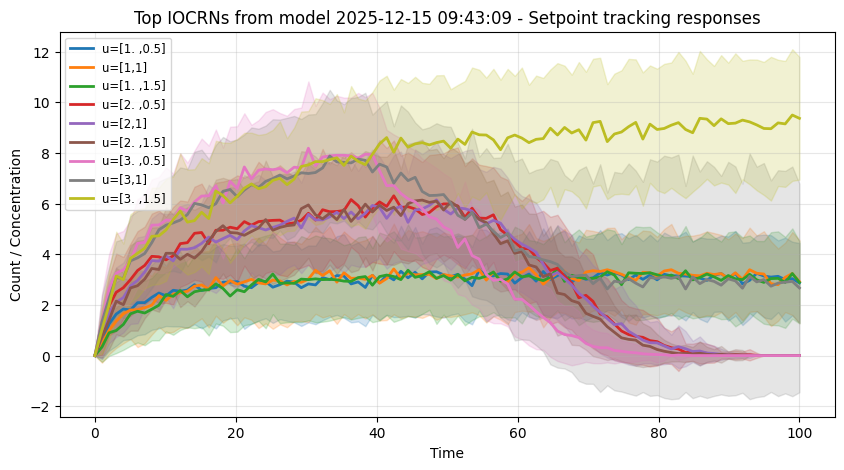

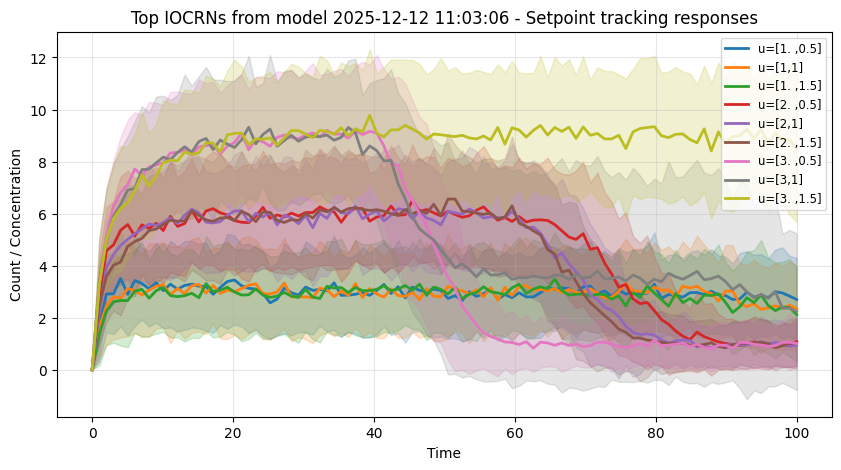

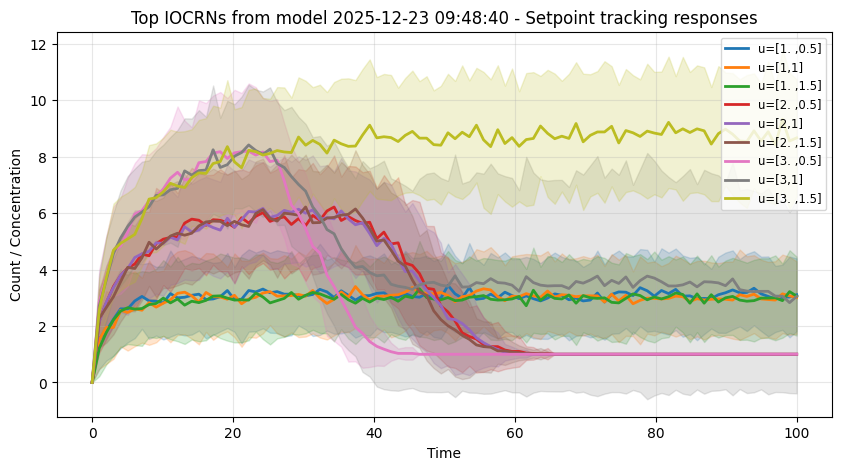

In [12]:
# Plot the results
for  j, sorted_crns_rewards in enumerate(sorted_crns_rewards_list):
    n_plot = 1
    ax = None
    for i in range(n_plot):
        x0_list = ic.get_ic(sorted_crns_rewards[i][0])
        (time_horizon, x_mean_list, y_mean_list, x_std_list, y_std_list, last_task_info) = sorted_crns_rewards[i][0].transient_response_SSA(u_list, x0_list, time_horizon)
        fig, ax = sorted_crns_rewards[i][0].plot_SSA_transient_response(alpha=0.2)
        model_name = os.path.basename(input_paths[j]).replace('.pth','')
        ax[0].set_title(f'Top IOCRNs from model {model_name} - Setpoint tracking responses')
        # print(f"IOCRN {i}, Reward: {sorted_crns_rewards[i][1]}")
        # print(sorted_crns_rewards[i][0])

In [13]:
if save_flag:
    for j, sorted_crns_rewards in enumerate(sorted_crns_rewards_list):
        load_filename = os.path.basename(input_paths[j]).replace('.pth','')
        output_path = os.path.join(target_directory, 'models', 'generated_' + load_filename + '.pth')
        print('Saving generated CRNs to file:','generated_' + output_path + '.pth')
        sorted_crns = [crn for crn, _ in sorted_crns_rewards]
        torch.save(sorted_crns, output_path)

Saving generated CRNs to file: generated_/local0/scratch/git/CRN-GenerativeAI/FINAL_nicolo/stochastic_RPA_3s_6r_MAK_REINFORCE/models/generated_2025-12-15 09:43:09.pth.pth
Saving generated CRNs to file: generated_/local0/scratch/git/CRN-GenerativeAI/FINAL_nicolo/stochastic_RPA_3s_6r_MAK_REINFORCE/models/generated_2025-12-12 11:03:06.pth.pth
Saving generated CRNs to file: generated_/local0/scratch/git/CRN-GenerativeAI/FINAL_nicolo/stochastic_RPA_3s_6r_MAK_REINFORCE/models/generated_2025-12-23 09:48:40.pth.pth
